# Defining the functions

In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt
import numpy as np
from dotenv import load_dotenv 

load_dotenv()

# --- 1. DYNAMIC PATH DISCOVERY (UPDATED TO .ENV) ---
def get_dataset_paths(dataset_name="cifar10"):
    """
    Constructs paths using the base path defined in the .env file.
    """
    base_path = os.getenv("DATA_BASE_PATH")
    
    if not base_path:
        raise ValueError("ERROR: No DATA_BASE_PATH assigned")

    paths = {
        "Original": os.path.join(base_path, f"raw/{dataset_name}_images"),
        "10% Randomized": os.path.join(base_path, f"processed/{dataset_name}_images_randomized_%10"),
        "Fully Randomized": os.path.join(base_path, f"processed/{dataset_name}_images_randomized")
    }
    return paths

# --- 2. CORE VISUALIZATION FUNCTION ---
def analyze_dataset(dataset_name="cifar10", specific_filename=None):
    """
    Main function to analyze and visualize randomization impact.
    Args:
        dataset_name (str): "cifar10" or "mnist"
        specific_filename (str): Optional. If provided, analyzes this specific file.
    """
    paths = get_dataset_paths(dataset_name)
    
    # Determine the correct extension (CIFAR is .bmp, MNIST is .png)
    ext = ".bmp" if dataset_name == "cifar10" else ".png"
    
    # 2.1 Find common files across variations
    try:
        orig = set(os.listdir(paths["Original"]))
        r10 = set(os.listdir(paths["10% Randomized"]))
        rf = set(os.listdir(paths["Fully Randomized"]))
        common = list(orig.intersection(r10).intersection(rf))
        common = [f for f in common if f.lower().endswith(ext)]
    except FileNotFoundError as e:
        print(f"Error: Could not access paths for {dataset_name}. {e}")
        return

    if not common:
        print(f"Error: No common images found for {dataset_name} using {ext} extension.")
        return

    # 2.2 Pick a file
    filename = specific_filename if specific_filename else random.choice(common)
    print(f"Dataset: {dataset_name.upper()} | Analyzing File: {filename}")

    # 2.3 Setup Plot (4 Rows: Original, Edge, FFT, Blur)
    plt.style.use('dark_background')
    fig, axes = plt.subplots(4, 3, figsize=(18, 16), gridspec_kw={'hspace': 0.4, 'wspace': 0.1})
    fig.patch.set_facecolor('#0a0a0a')

    keys = ["Original", "10% Randomized", "Fully Randomized"]
    colors = ["#00f2ff", "#ff007b", "#f9ff00", "#00ff41"] # Title colors

    for i, key in enumerate(keys):
        img_path = os.path.join(paths[key], filename)
        img_bgr = cv2.imread(img_path)
        if img_bgr is None: continue
        
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        
        # Analytic filters
        edges = cv2.Canny(cv2.GaussianBlur(gray, (3, 3), 0), 100, 200)
        dft = np.fft.fft2(gray)
        dft_shift = np.fft.fftshift(dft)
        mag_spec = 20 * np.log(np.abs(dft_shift) + 1)
        blur = cv2.GaussianBlur(img_rgb, (5, 5), 0)

        # Row 1: Source
        axes[0, i].imshow(img_rgb)
        axes[0, i].set_title(f"{key} Image", color=colors[0], fontweight='bold')
        axes[0, i].axis('off')
        
        # Row 2: Edges
        axes[1, i].imshow(edges, cmap='magma')
        axes[1, i].set_title("Edge Detection", color=colors[1])
        axes[1, i].axis('off')

        # Row 3: FFT
        axes[2, i].imshow(mag_spec, cmap='viridis')
        axes[2, i].set_title("Frequency (FFT)", color=colors[2])
        axes[2, i].axis('off')

        # Row 4: Blur
        axes[3, i].imshow(blur)
        axes[3, i].set_title("Gaussian Smoothing", color=colors[3])
        axes[3, i].axis('off')

    plt.suptitle(f"{dataset_name.upper()} Randomization Analysis\nFile: {filename}", 
                 color='white', fontsize=26, fontweight='black', y=0.98)
    
    plt.tight_layout()
    plt.show()

# Randomly chacking "cifar10" images

Dataset: CIFAR10 | Analyzing File: felis_catus_s_001159.bmp


/tmp/ipykernel_21087/1821930762.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


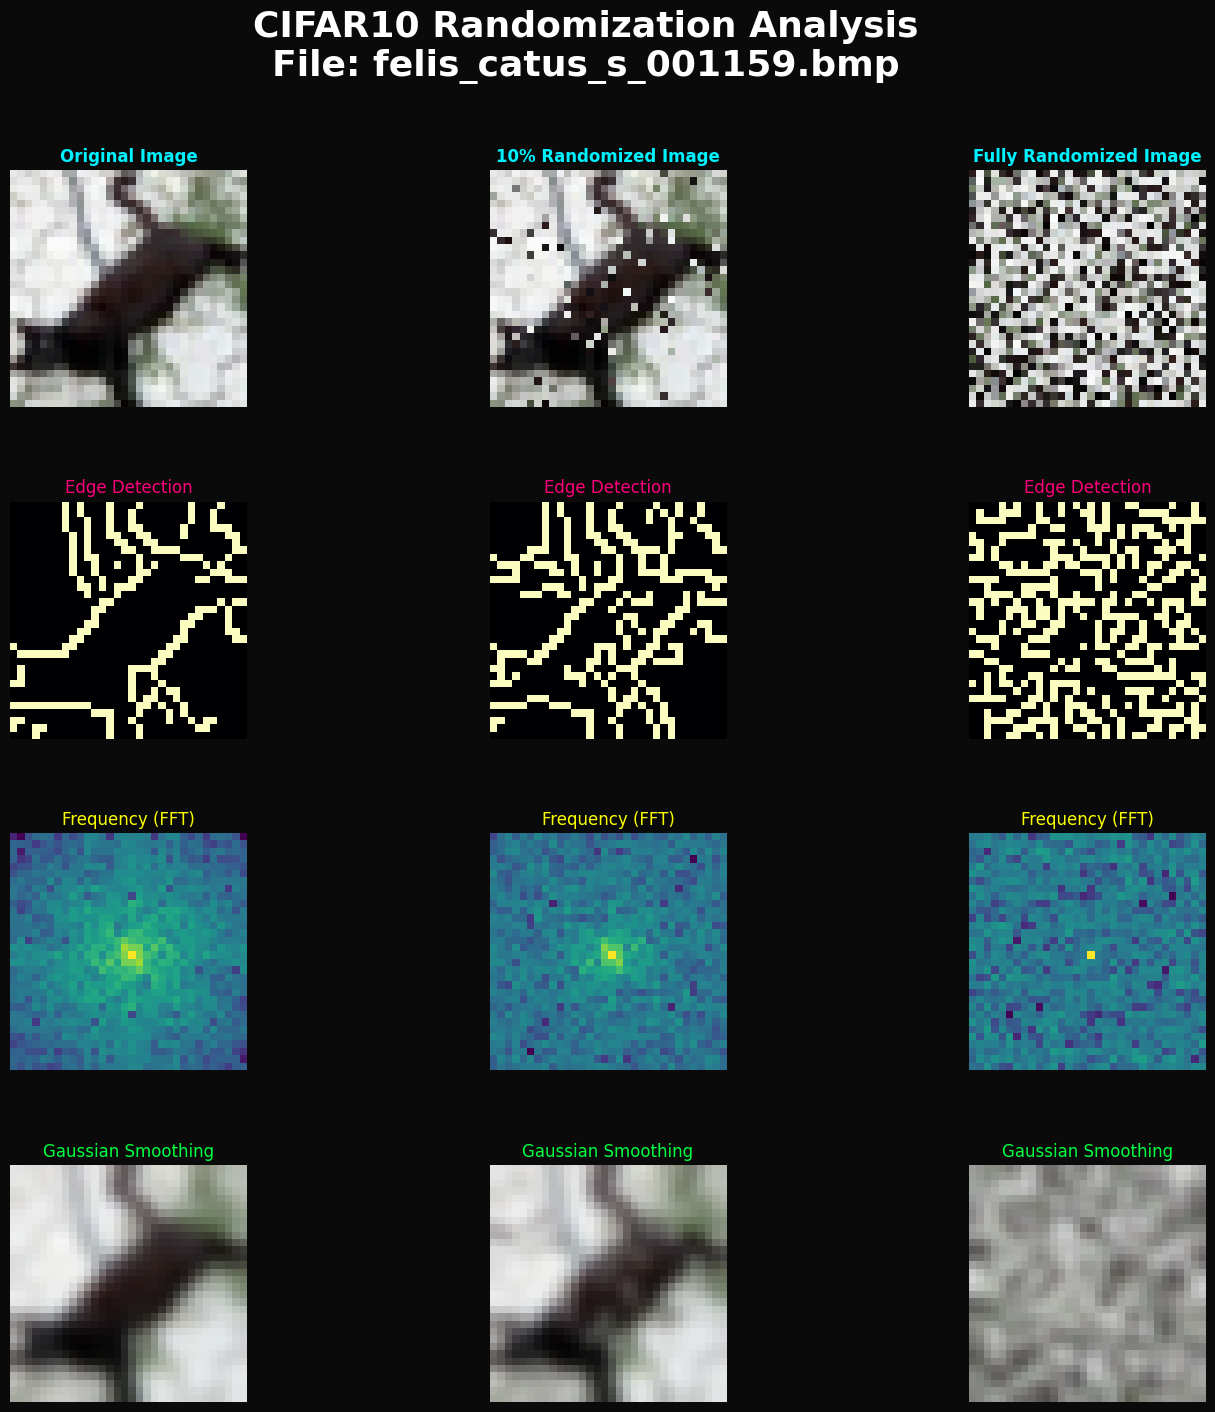

In [4]:
# --- 3. RUNTIME SELECTION ---
# You can change the parameter here: "cifar10" or "mnist"
analyze_dataset(dataset_name="cifar10") 

Dataset: CIFAR10 | Analyzing File: stud_mare_s_001322.bmp


/tmp/ipykernel_21087/1821930762.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


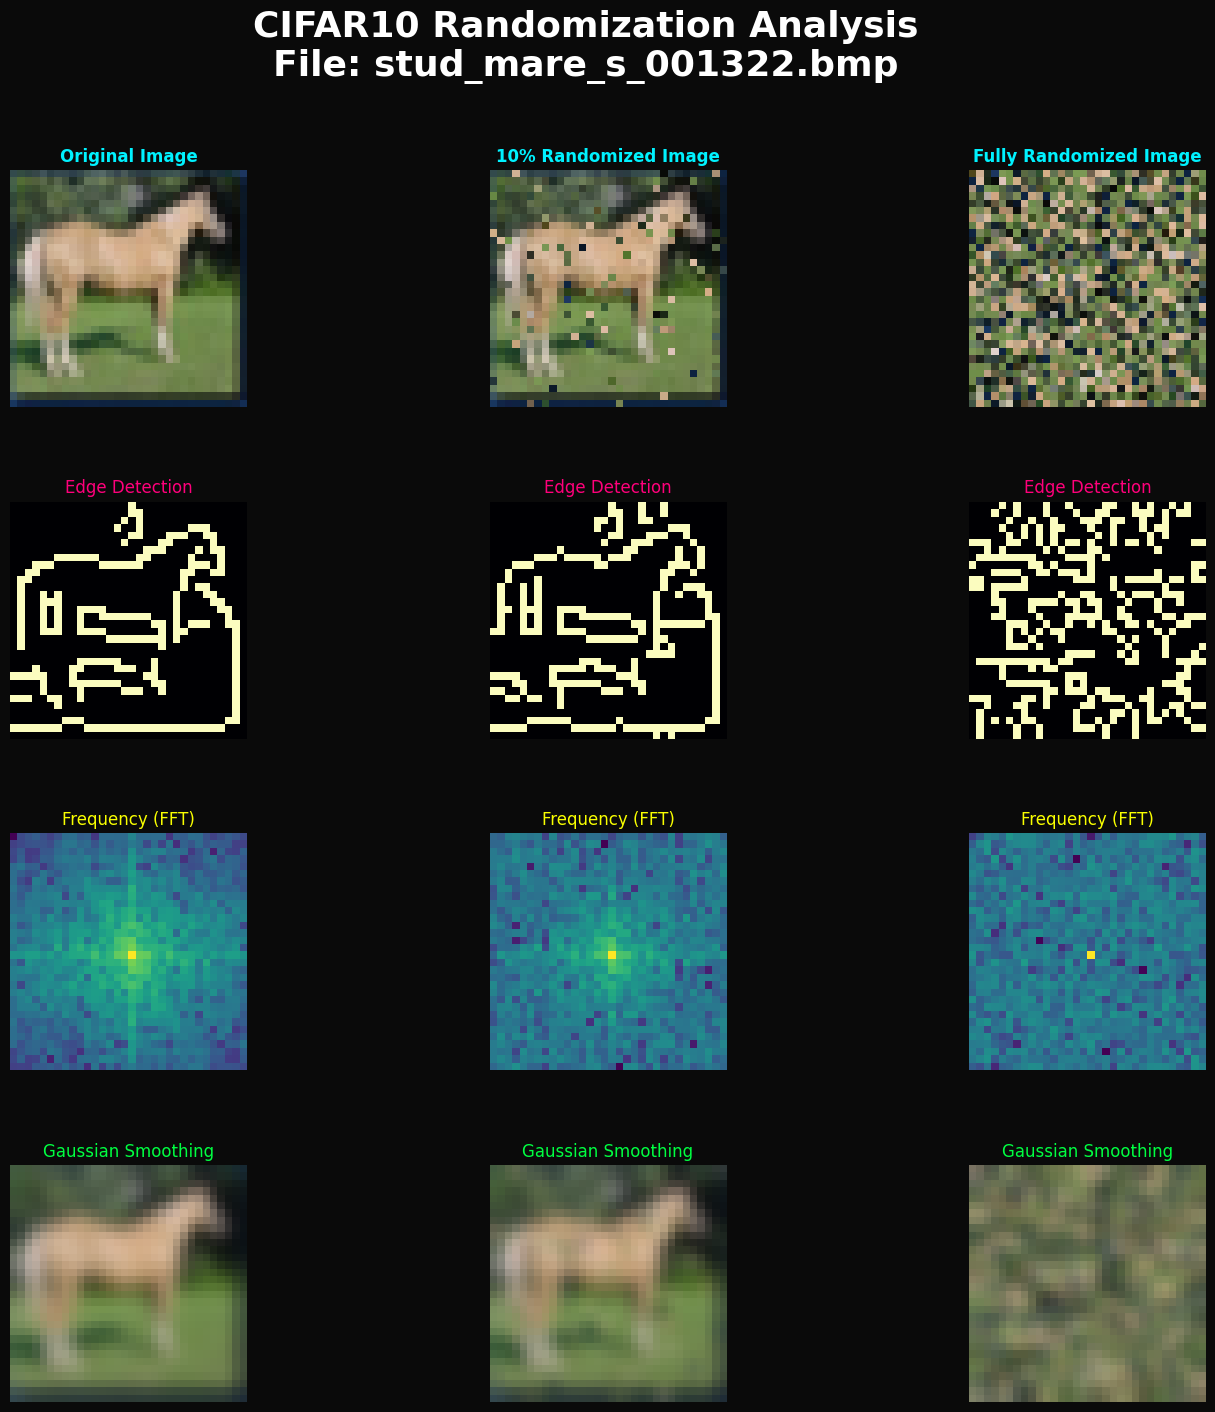

In [5]:
analyze_dataset(dataset_name="cifar10")

Dataset: CIFAR10 | Analyzing File: attack_aircraft_s_001419.bmp


/tmp/ipykernel_21087/1821930762.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


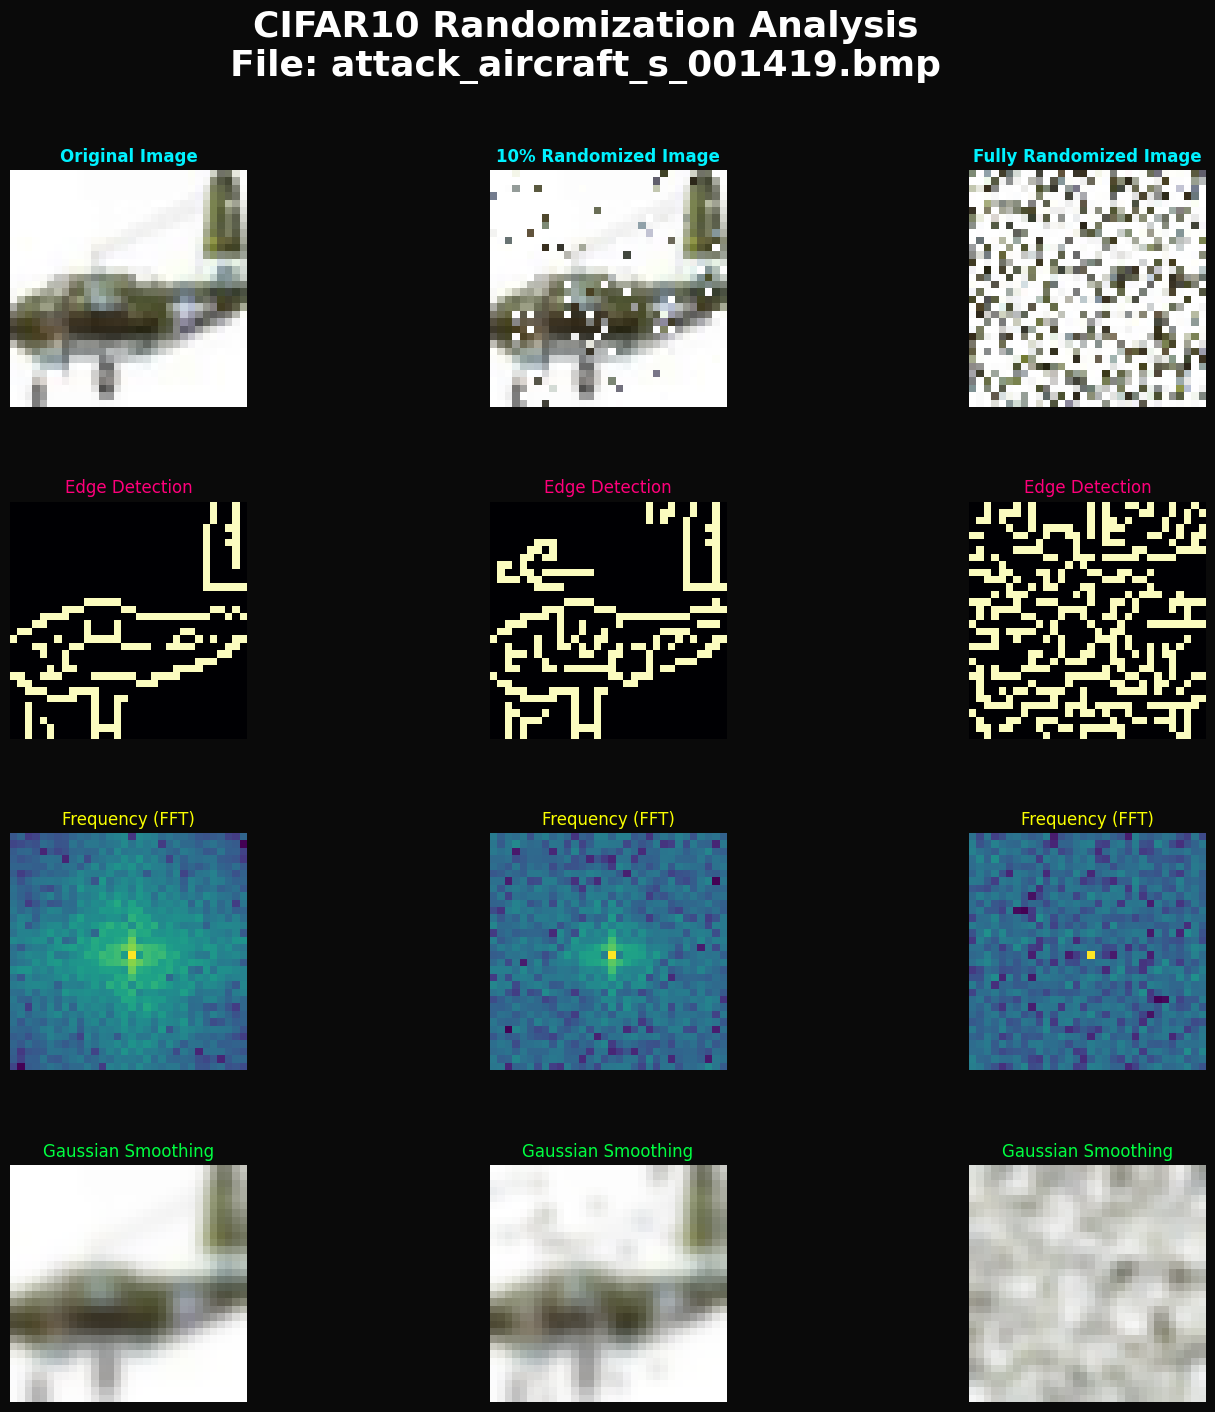

In [6]:
analyze_dataset(dataset_name="cifar10")

Dataset: CIFAR10 | Analyzing File: fighter_aircraft_s_000564.bmp


/tmp/ipykernel_21087/1821930762.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


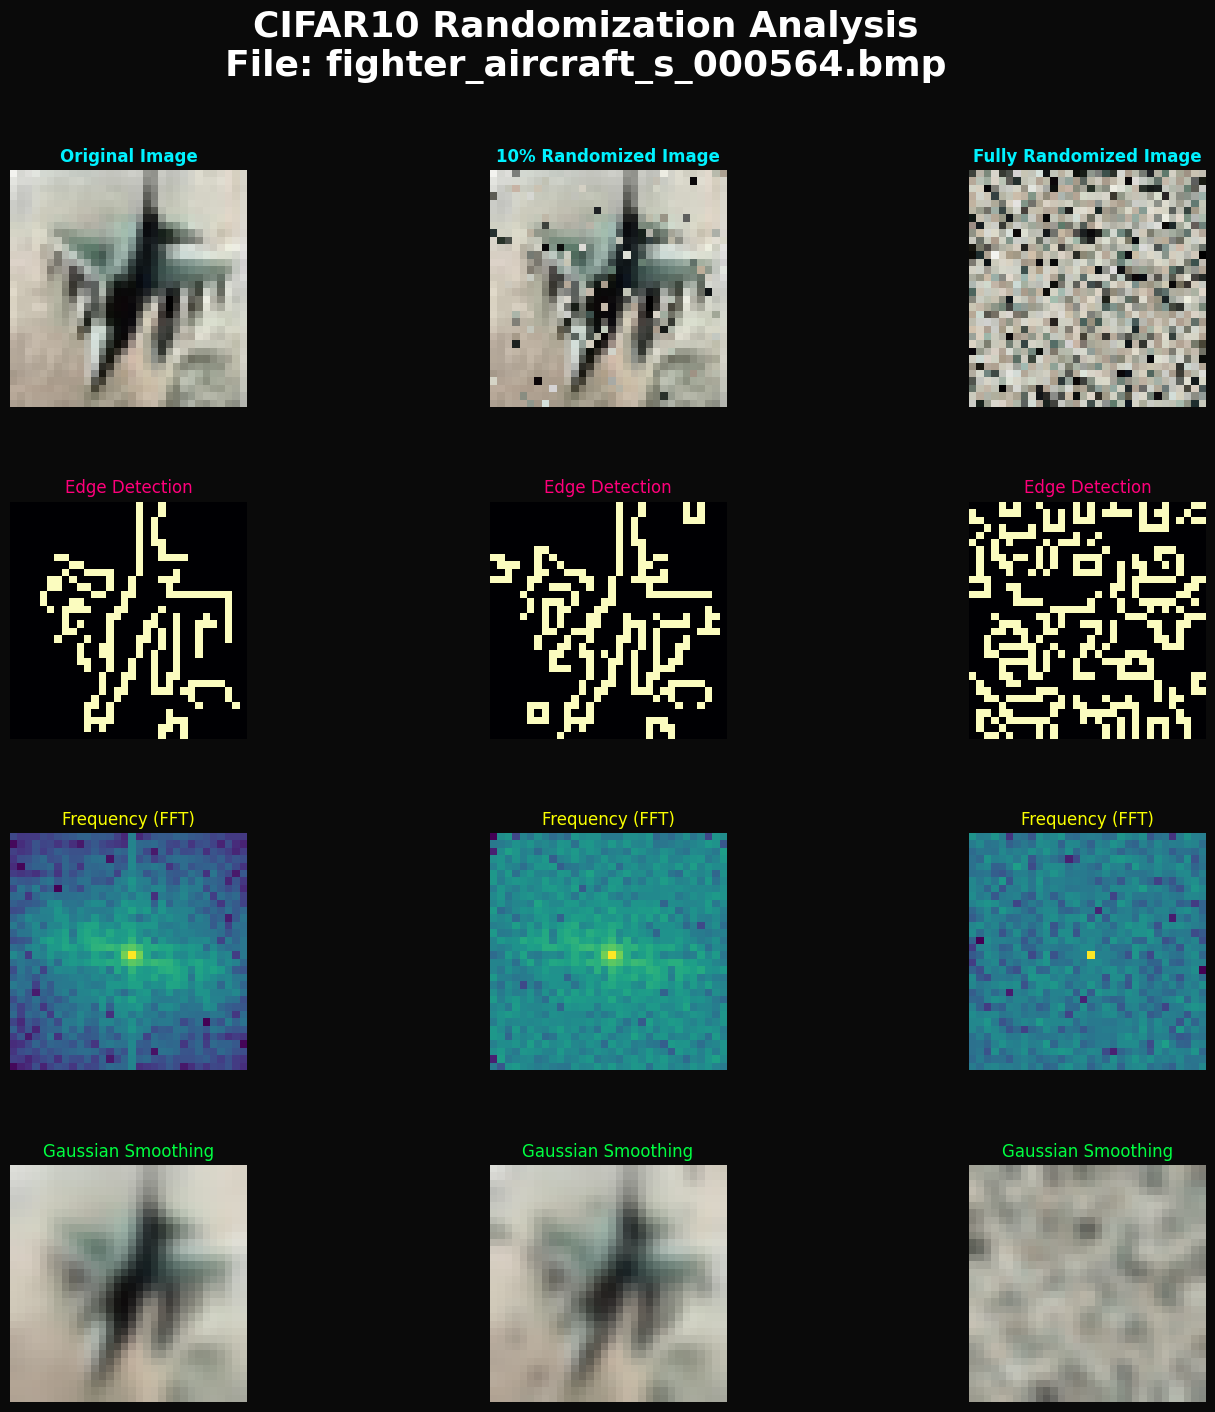

In [7]:
analyze_dataset(dataset_name="cifar10")

# Randomly chacking "mnist" images

Dataset: MNIST | Analyzing File: train_38157.png


/tmp/ipykernel_21087/2457137423.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


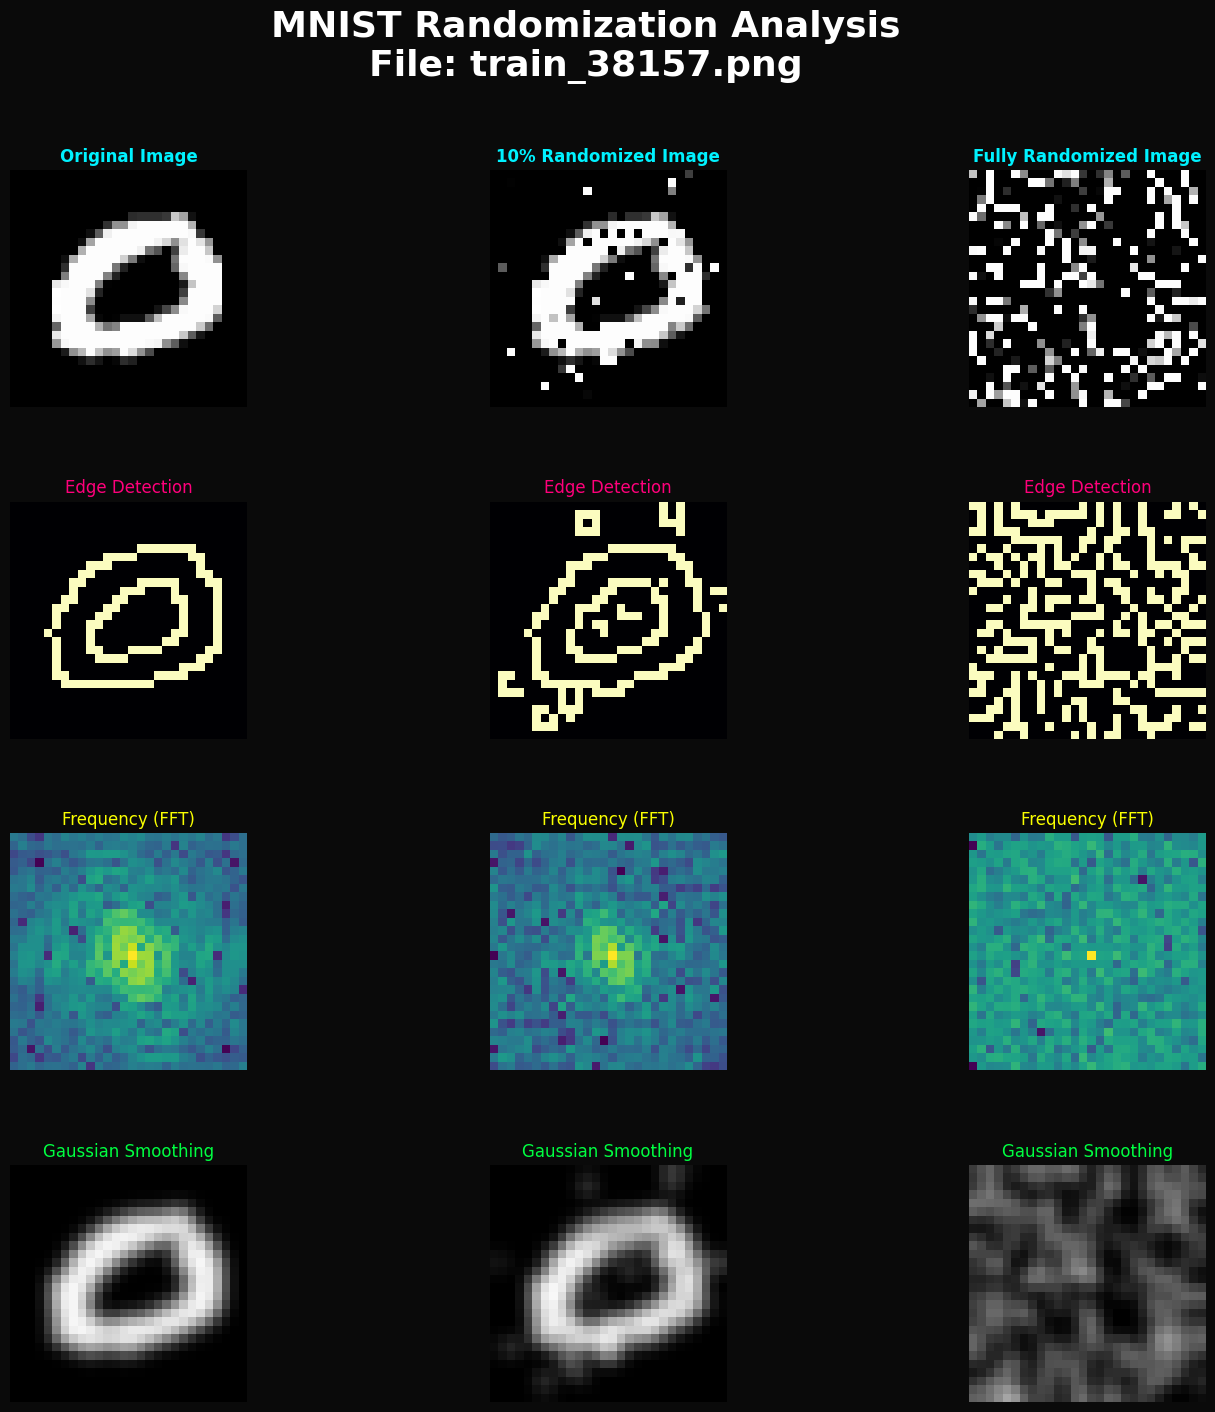

In [2]:
analyze_dataset(dataset_name="mnist")

Dataset: MNIST | Analyzing File: train_42924.png


/tmp/ipykernel_21087/1821930762.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


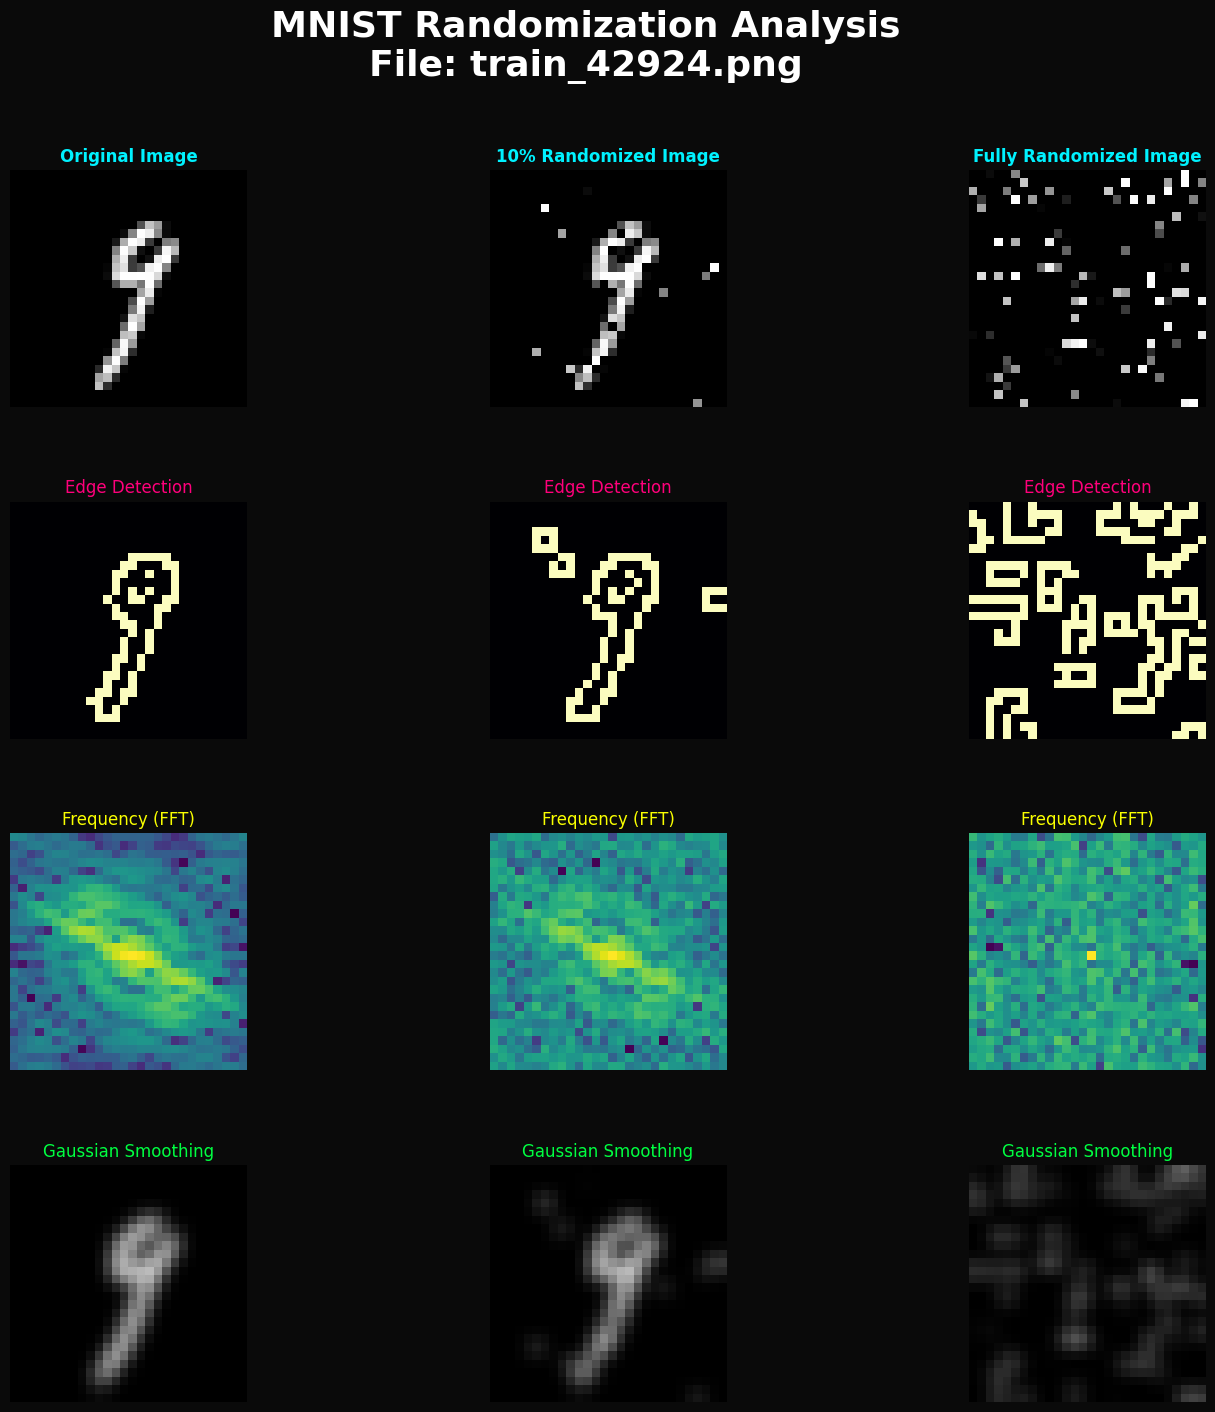

In [10]:
analyze_dataset(dataset_name="mnist")

Dataset: MNIST | Analyzing File: train_05200.png


/tmp/ipykernel_21087/1821930762.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


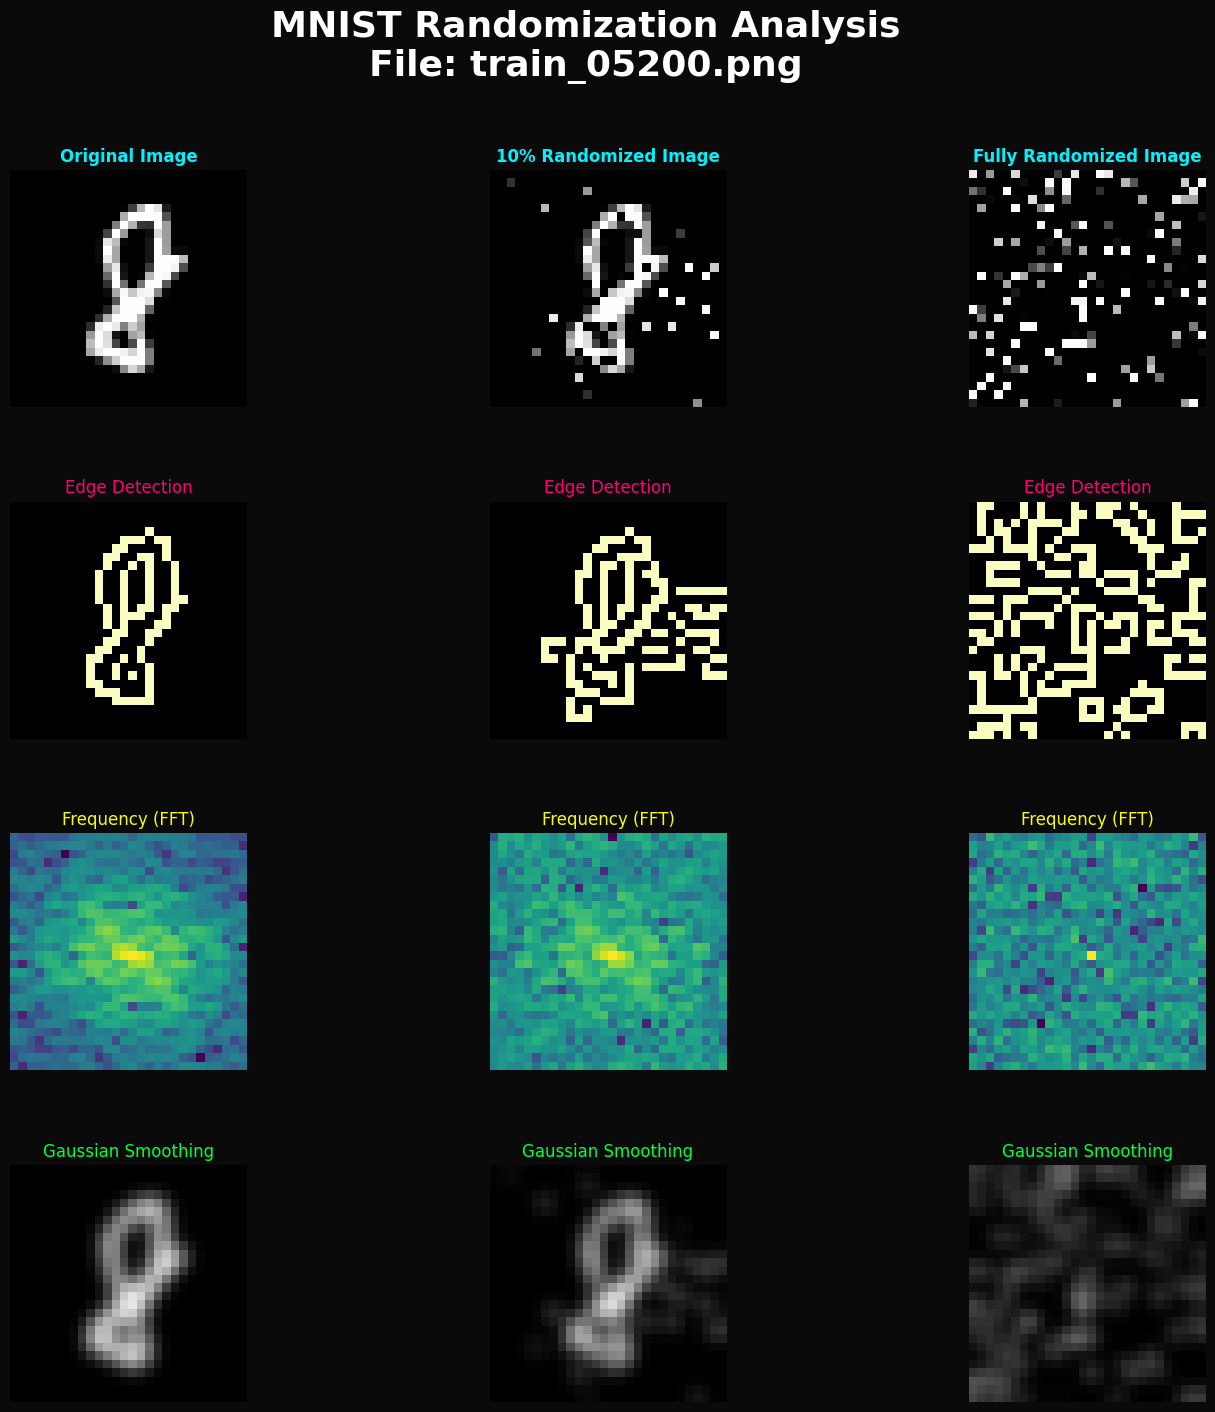

In [11]:
analyze_dataset(dataset_name="mnist")

Dataset: MNIST | Analyzing File: train_24807.png


/tmp/ipykernel_21087/1821930762.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


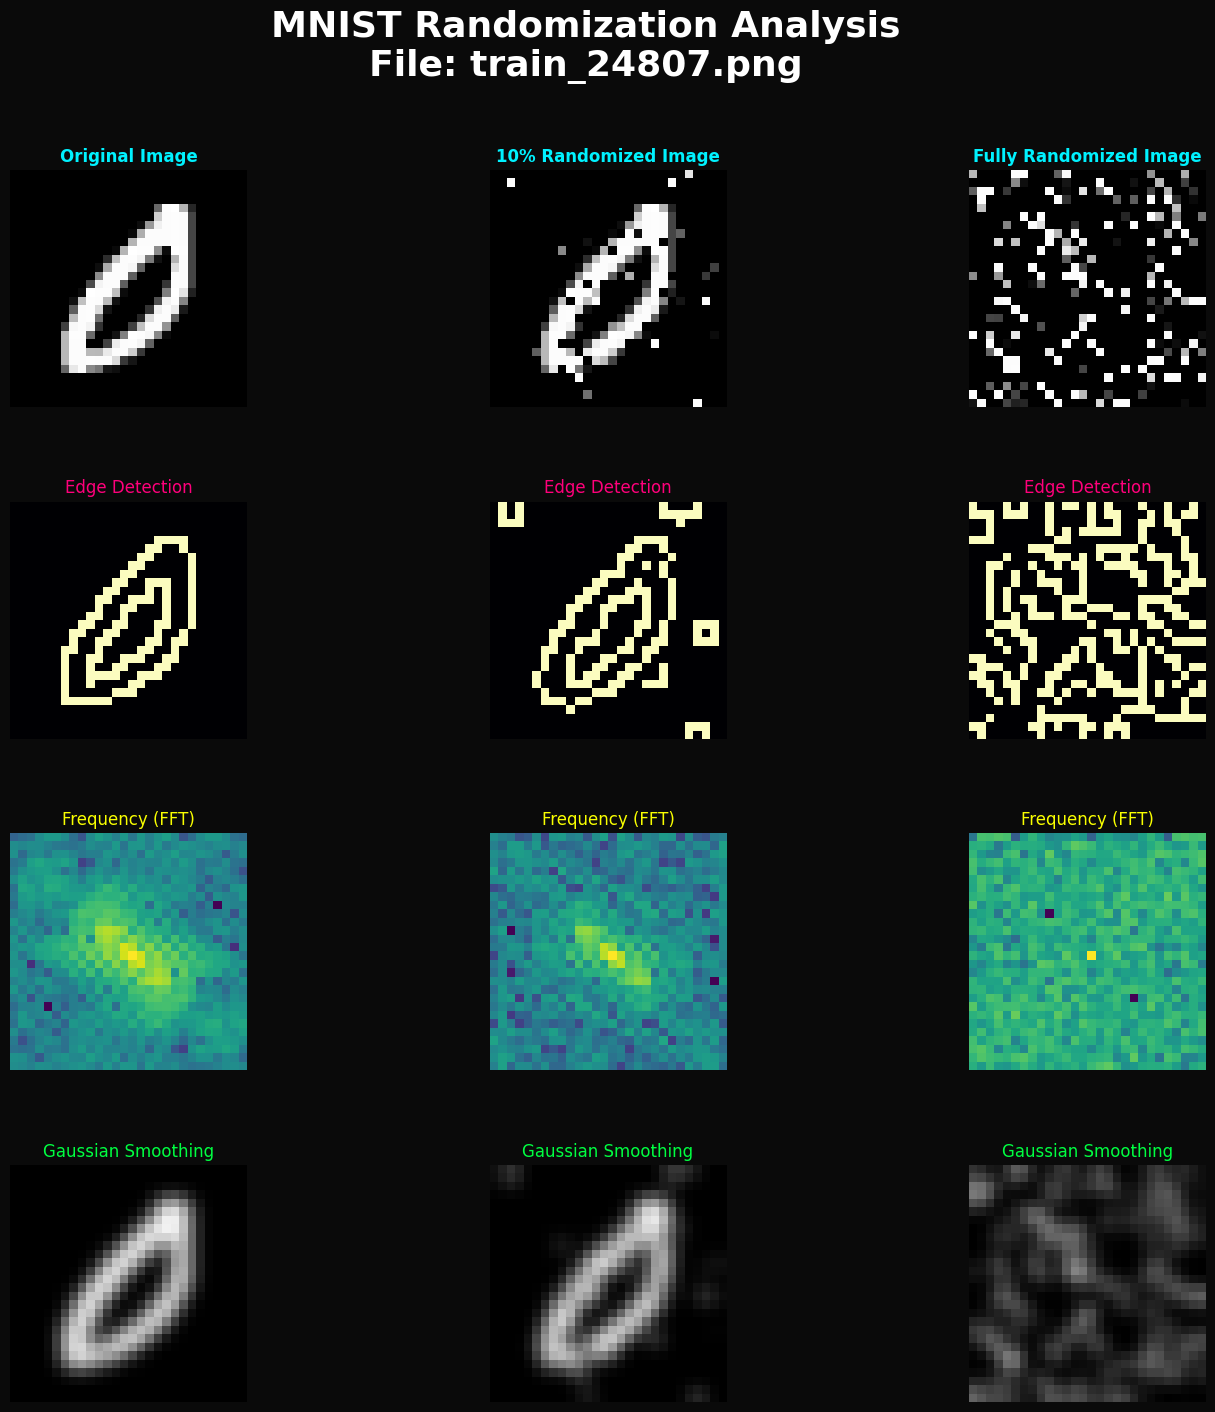

In [9]:
analyze_dataset(dataset_name="mnist")

# Conclusion

The observations showed that 10% of the data were random, preserving some meaningful data, while in completely random groups, the amount of meaningful data was close to zero.